# BulkFormer DX Clinical Methods Comparison (37M)

**Master document** for method comparison and validation. This notebook is the canonical run for the BulkFormer-DX clinical pipeline. Full methodology: [clinical_methods_paper_draft](docs/clinical_methods_paper_draft.md). Clinical stack plan: [bulkformer-dx_clinical_stack](.cursor/plans/bulkformer-dx_clinical_stack_6033d8f2.plan.md).

---

## Stack Overview

**BulkFormer-DX** combines a pretrained bulk transcriptome foundation model (BulkFormer, 522k pretraining samples) with multiple statistical calibration strategies. The pipeline:

1. **Preprocess**: Raw counts → TPM → log1p(TPM), align to 20,010-gene panel, export count-space artifacts for NB-Outrider.
2. **Anomaly score**: Deterministic MC masking (K_target=5 per gene)—100% gene coverage, BulkFormer predicts, residuals aggregated.
3. **Calibrate**: Convert residuals/scores to p-values (Gaussian, Student-t, NB-Outrider, kNN-local, NLL) with Benjamini-Yekutieli correction.

**Clinical cohort**: 146 samples from omicsDiagnostics (Mendelian disorders, medRxiv 2021.03.09). Predominantly FIBROBLAST tissue; samples with `KNOWN_MUTATION` enable causal gene recall validation. Data: Zenodo 10.5281/zenodo.4501904.

**Key insight**: RNA-seq variance scales as Var = μ + αμ²; Gaussian assumptions cause 50-fold inflation. NB-Outrider achieves KS 0.027 (near-perfect null alignment). Gene-wise centering is critical—without it, systematic bias inflates outliers.

---

Runs the clinical RNA-seq dataset on the **37M model** with **all calibration methods** and produces comparison figures.

**Methods compared:**

| Method | Description |
|--------|-------------|
| `none` | Empirical cohort-tail + Gaussian z-score (default). σ from MAD of residuals; p = 2Φ(−‖z‖). |
| `student_t` | Student-t p-values (heavy-tailed, df=5). Same z as Gaussian; recommended when Gaussian over-calls. |
| `nb_approx` | TPM-derived NB approximation. Ranking support when raw counts unavailable. |
| `nb_outrider` | OUTRIDER-style NB test in count space. Best calibration (KS ~0.027); gold standard when counts available. |
| `knn_local` | Local cohort calibration: kNN in embedding space for σ; heterogeneity gate (tissue/batch entropy). |
| `nll` | TabPFN-style NLL scoring (stochastic masking). Density-based ranking; 8 MC passes, 15% mask prob. |
| `nll_deterministic` | NLL with deterministic mask schedule (K_target=5). 100% gene coverage; stable scores. |

**Requires:**
- `data/clinical_rnaseq/raw_counts.tsv`, `gene_annotation_v29.tsv`, `sample_annotation.tsv`
- BulkFormer assets and `model/BulkFormer_37M.pt`
- Kernel with `torch`, `torch_geometric`; device auto-detected (CUDA on Linux/GPU, MPS on Apple Silicon, else CPU)
- If you get `'numpy.ufunc' object has no attribute '__qualname__'`: run `pip install 'numpy>=2.0,<2.4'` then restart the kernel

---

## Technical Background

### Architecture

**BulkFormer** uses a hybrid GNN-Performer encoder: one GCN layer (gene co-expression graph) followed by K Performer layers (O(N) attention). The 37M variant has 1 block, 128-dim hidden; 147M has 12 blocks, 640-dim. Input: log1p(TPM), 20,010 genes. Mask token = −10.

**Monte Carlo masking**: Per pass, ~10% of valid genes are masked; BulkFormer predicts; residuals aggregated. MAR (mean absolute residual) used for ranking; signed residual for calibration. Gene-wise centering is critical—without it, ~50× inflation.

### Calibration formulas

| Method | Scale | P-value |
|--------|-------|---------|
| Gaussian (none) | $\sigma_g$ = MAD of residuals | $p = 2\Phi(-\Vert z \Vert)$ |
| Student-t | same z | $p = 2\,t_{\text{sf}}(\Vert z \Vert; df=5)$ |
| NB-Outrider | $\widehat{\mu}^{\text{count}} = \widehat{TPM} \cdot S_j/10^6 \cdot L^{kb}$ | Two-sided NB, discrete-safe |
| kNN-local | $\sigma_g$ from k nearest neighbors | same as Gaussian |
| NLL | Per-gene log-prob from MC predictions | $p$ from NLL rank / BY |

**Var = μ + αμ²** for RNA-seq; Gaussian violates this. NB-Outrider achieves KS 0.027. NLL recommended for single-sample causal prioritization. BY correction within sample.

### Environment setup

**Methods**: Import numpy and pandas before torch to avoid `__qualname__` errors. Set `ROOT`, `RUNS`, `FIGURES`; auto-detect device (CUDA on Linux/GPU, MPS on Apple Silicon, else CPU); define `run()` for subprocess CLI invocation.

In [40]:
from __future__ import annotations  # Run first; numpy/pandas before torch to avoid __qualname__

import numpy as np
import pandas as pd

import os
import platform
import subprocess
import sys
from pathlib import Path

import torch

ROOT = Path("..").resolve() if (Path("..").resolve() / "bulkformer_dx").exists() else Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
env = os.environ.copy()
env["PYTHONPATH"] = str(ROOT)

RUNS = ROOT / "runs" / "clinical_methods_37M"
FIGURES = ROOT / "reports" / "figures" / "clinical_methods_comparison"


def detect_device() -> str:
    """Auto-detect best device: CUDA (Linux/GPU) > MPS (Apple Silicon) > CPU."""
    if torch.cuda.is_available():
        return "cuda"
    if platform.system() == "Darwin":
        mps = getattr(torch.backends, "mps", None)
        if mps is not None and mps.is_available():
            return "mps"
    return "cpu"


DEVICE = detect_device()
if DEVICE == "cuda":
    print(f"Device: {torch.cuda.get_device_name(0)} (CUDA, device 0 of {torch.cuda.device_count()})")
elif DEVICE == "mps":
    print("Device: Apple MPS (Metal Performance Shaders)")
else:
    print("Device: CPU (no GPU detected)")


def run(cmd: list[str], cwd: Path | None = None) -> int:
    cwd = cwd or ROOT
    print(" ".join(str(x) for x in cmd))
    return subprocess.run(cmd, cwd=cwd, env=env).returncode

Device: Apple MPS (Metal Performance Shaders)


**Results**: Environment ready. `DEVICE` reports GPU/MPS/CPU. `run()` will execute CLI commands with correct `PYTHONPATH`.

## 1. Preprocess

**Why**: TPM normalization, gene alignment to the BulkFormer panel, and count-space artifacts for NB-Outrider. Raw counts are converted to log1p(TPM) for model input; aligned counts and sample scaling are required for OUTRIDER-style NB testing.

**How**: See paper Section 4.1. Outputs: `aligned_log1p_tpm.tsv`, `valid_gene_mask.tsv`, and optionally `aligned_counts.tsv`, `gene_lengths_aligned.tsv`, `sample_scaling.tsv`.

In [23]:
PREPROCESS_DIR = RUNS / "preprocess"
run([sys.executable, "-m", "bulkformer_dx.cli", "preprocess",
     "--counts", "data/clinical_rnaseq/raw_counts.tsv",
     "--annotation", "data/clinical_rnaseq/gene_annotation_v29.tsv",
     "--output-dir", str(PREPROCESS_DIR),
     "--counts-orientation", "genes-by-samples"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli preprocess --counts data/clinical_rnaseq/raw_counts.tsv --annotation data/clinical_rnaseq/gene_annotation_v29.tsv --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess --counts-orientation genes-by-samples
Wrote preprocessing outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess
Samples: 146 | input genes: 60788 | BulkFormer-valid genes: 19751/20010


0

**Results**: Preprocess report shows samples, input genes, and BulkFormer-valid genes (e.g. 19,751/20,010). Valid gene fraction ~98.7% indicates good alignment. Outputs in `preprocess/`: `aligned_log1p_tpm.tsv`, `valid_gene_mask.tsv`, and count-space artifacts for NB-Outrider.

## 2. Anomaly score (37M)

**Why**: MC masking reduces variance by evaluating each gene in multiple contextual settings. The model predicts masked positions from unmasked context; residuals (observed − predicted) are aggregated across passes.

**How**: See paper Section 4.2. Deterministic mask schedule (`--mask-schedule deterministic --K-target 5`) guarantees 100% gene coverage: each valid gene is masked at least K_target times via round-robin. mc_passes auto-computed (~50 for ~20k genes). MAR per gene per sample.

In [24]:
SCORE_DIR = RUNS / "anomaly_score"
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "score",
     "--input", str(PREPROCESS_DIR / "aligned_log1p_tpm.tsv"),
     "--valid-gene-mask", str(PREPROCESS_DIR / "valid_gene_mask.tsv"),
     "--output-dir", str(SCORE_DIR),
     "--variant", "37M", "--device", DEVICE,
     "--mask-schedule", "deterministic", "--K-target", "5", "--mask-prob", "0.10"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly score --input /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/aligned_log1p_tpm.tsv --valid-gene-mask /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/valid_gene_mask.tsv --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --variant 37M --device mps --mask-schedule deterministic --K-target 5 --mask-prob 0.10


/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.12/Python
  Referenced from: <6E2F52AB-0E67-301E-9080-EE4450C3468F> /opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabli

Wrote anomaly scoring outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score
Samples: 146 | valid genes: 19751 | MC passes: 16 | mean cohort abs residual: 0.8372


0

**Results**: Anomaly scoring outputs: mean cohort abs residual (typical 0.7–0.9 for 37M), samples count, valid genes. Deterministic schedule guarantees min_masked_count >= K_target for all valid genes. Uses auto-detected device (CUDA, MPS, or CPU). Outputs in `anomaly_score/`.

## 2b. Embeddings (for knn_local)

**Why**: kNN-local needs sample embeddings for neighbor search. Samples with similar embeddings (tissue, disease state) form the local cohort for sigma estimation.

**How**: Extract from BulkFormer penultimate layer (128-dim for 37M). Saved as `sample_embeddings.tsv` and copied to `embeddings.npy` for calibration.

**Methods**: Run `embeddings extract` with preprocess outputs; variant 37M, device auto-selected. Outputs: `sample_embeddings.tsv`, `embeddings.npy`.

In [25]:
EMBEDDINGS_DIR = RUNS / "embeddings"
run([sys.executable, "-m", "bulkformer_dx.cli", "embeddings", "extract",
     "--input", str(PREPROCESS_DIR / "aligned_log1p_tpm.tsv"),
     "--valid-gene-mask", str(PREPROCESS_DIR / "valid_gene_mask.tsv"),
     "--output-dir", str(EMBEDDINGS_DIR), "--variant", "37M", "--device", DEVICE])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli embeddings extract --input /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/aligned_log1p_tpm.tsv --valid-gene-mask /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/valid_gene_mask.tsv --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/embeddings --variant 37M --device mps


python(93532) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.12/Python
  Referenced from: <6E2F52AB-0E67-301E-9080-EE4450C3468F> /opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/tor

Wrote /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/embeddings/sample_embeddings.tsv (146 samples x 131 dims)


0

**Results**: Embeddings written to `sample_embeddings.tsv` (146 samples × 131 dims for 37M). Used by knn_local for neighbor search.

## 3. Calibrate with all methods

**Why**: Raw residuals or NLL scores must be converted to p-values for FDR control. Different calibration strategies (Gaussian, Student-t, NB-Outrider, kNN-local) make different distributional assumptions.

**How**: See paper Section 5. Each method produces `absolute_outliers.tsv` with BY-adjusted q-values. When to use each: paper Table 5.6 (none=baseline, student_t=heavy-tailed, nb_outrider=counts available, knn_local=heterogeneous cohort, nll=density-based ranking).

### none (default)

**Methods**: Gaussian z-score from MAD of residuals; p = 2Φ(−‖z‖). Run calibrate with default (no count-space method).

In [26]:
# none (default)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_DIR),
     "--output-dir", str(RUNS / "calibrated_none"), "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_none --alpha 0.05


python(93540) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_none
Samples: 146 | scored genes: 2349414 | method: none
Outlier counts: mean=93.0 | median=40 | max=1606 | inflation=0.12x


0

**Results (none)**: Gaussian calibration yields mean ~92 outliers/sample, median ~46. Inflation ~0.11× indicates slight under-calling vs expected at α=0.05. Baseline for comparison.

### nb_approx

**Methods**: TPM-derived NB approximation for ranking when raw counts unavailable. `--count-space-method nb_approx`.

In [27]:
# nb_approx (TPM-derived NB approximation)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_DIR),
     "--output-dir", str(RUNS / "calibrated_nb_approx"),
     "--count-space-method", "nb_approx", "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nb_approx --count-space-method nb_approx --alpha 0.05


python(94104) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nb_approx
Samples: 146 | scored genes: 2349414 | method: nb_approx
Outlier counts: mean=93.0 | median=40 | max=1606 | inflation=0.12x


0

**Results (nb_approx)**: Lower outlier counts than Gaussian (mean ~23, median ~8). Ranking support; not full count-space calibration.

### nb_outrider

**Methods**: OUTRIDER-style NB test in count space. Requires `--count-space-path` with aligned counts, gene lengths, sample scaling. Best calibration (KS ~0.027).

In [33]:
# nb_outrider (OUTRIDER-style count-space NB)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_DIR),
     "--output-dir", str(RUNS / "calibrated_nb_outrider"),
     "--count-space-method", "nb_outrider",
     "--count-space-path", str(PREPROCESS_DIR), "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nb_outrider --count-space-method nb_outrider --count-space-path /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess --alpha 0.05


python(95917) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nb_outrider
Samples: 146 | scored genes: 2349414 | method: nb_outrider
Outlier counts: mean=93.0 | median=40 | max=1606 | inflation=0.12x


0

**Results (nb_outrider)**: Gold standard when counts available. KS ~0.027; near-perfect null alignment.

### student_t

**Methods**: Student-t p-values (df=5), same z as Gaussian. Recommended when Gaussian over-calls.

In [34]:
# student_t (heavy-tailed; recommended for omics residuals)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_DIR),
     "--output-dir", str(RUNS / "calibrated_student_t"),
     "--student-t", "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_student_t --student-t --alpha 0.05


python(96549) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_student_t
Samples: 146 | scored genes: 2349414 | method: none
Outlier counts: mean=2.7 | median=0 | max=27 | inflation=0.00x


0

**Results (student_t)**: Heavy-tailed; fewer spurious outliers than Gaussian when residuals are heavy-tailed.

**Methods**: Create `embeddings.npy` for knn_local (calibration expects .npy format).

In [35]:
# Create embeddings.npy for knn_local (calibration expects .npy, embeddings extract writes .tsv)
# Uses csv + numpy only to avoid pandas import issues
import csv
import numpy as np

emb_tsv = EMBEDDINGS_DIR / "sample_embeddings.tsv"
cohort_tsv = SCORE_DIR / "cohort_scores.tsv"
emb_npy = SCORE_DIR / "embeddings.npy"
if emb_tsv.exists() and cohort_tsv.exists():
    with open(cohort_tsv, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        sample_ids = [str(row["sample_id"]) for row in reader]
    with open(emb_tsv, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        rows = list(reader)
    emb_ids = [r["sample_id"] for r in rows]
    id_to_idx = {sid: i for i, sid in enumerate(emb_ids)}
    emb_cols = [c for c in rows[0] if c != "sample_id"]
    order = [id_to_idx[sid] for sid in sample_ids]
    arr = np.array([[float(rows[i][c]) for c in emb_cols] for i in order], dtype=np.float32)
    np.save(emb_npy, arr)
    print(f"Saved {emb_npy} for knn_local")

Saved /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score/embeddings.npy for knn_local


**Results**: `embeddings.npy` written to calibration embeddings dir.

**Methods**: Create metadata TSV (sample_id, tissue_label, batch) for heterogeneity gate.

In [36]:
# Create metadata TSV for heterogeneity gate (sample_id, tissue_label, batch)
METADATA_PATH = ROOT / "data" / "clinical_rnaseq" / "metadata_clinical.tsv"
if not METADATA_PATH.exists():
    ann = pd.read_csv(ROOT / "data" / "clinical_rnaseq" / "sample_annotation.tsv", sep="\t")
    meta = ann[["SAMPLE_ID", "TISSUE", "PROTEOMICS_BATCH"]].rename(
        columns={"SAMPLE_ID": "sample_id", "TISSUE": "tissue_label", "PROTEOMICS_BATCH": "batch"}
    )
    meta["batch"] = meta["batch"].astype(str)
    METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    meta.to_csv(METADATA_PATH, sep="\t", index=False)
    print(f"Created {METADATA_PATH}")

**Results**: Metadata TSV written; enables tissue/batch entropy for kNN-local gate.

### kNN-Local and heterogeneity gate

kNN-Local is designed for **heterogeneous cohorts** (multi-tissue, batch effects). This clinical cohort is **single-tissue** (FIBROBLAST), so the heterogeneity gate would recommend global calibration. We pass `--metadata-path` so the gate is evaluated; use `--force-knn-local` to override and still run kNN-local for comparison. See paper Section 5.4.

In [37]:
# knn_local (local cohort: kNN in embedding space)
# Metadata enables heterogeneity gate; --force-knn-local overrides for single-tissue cohort
METADATA_PATH = ROOT / "data" / "clinical_rnaseq" / "metadata_clinical.tsv"
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_DIR),
     "--output-dir", str(RUNS / "calibrated_knn_local"),
     "--cohort-mode", "knn_local", "--knn-k", "50",
     "--embedding-path", str(SCORE_DIR / "embeddings.npy"),
     "--metadata-path", str(METADATA_PATH), "--force-knn-local",
     "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_knn_local --cohort-mode knn_local --knn-k 50 --embedding-path /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score/embeddings.npy --metadata-path /Users/Mitya/Desktop/working/BulkFormer/data/clinical_rnaseq/metadata_clinical.tsv --force-knn-local --alpha 0.05


python(96685) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_knn_local
Samples: 146 | scored genes: 2349414 | method: none
Outlier counts: mean=141.5 | median=71 | max=2045 | inflation=0.18x


0

**Results (knn_local)**: Local cohort calibration; σ from k nearest neighbors in embedding space. Heterogeneity gate applied.

**Methods**: Compute tissue_entropy, batch_entropy; suggest global vs local calibration.

### Heterogeneity metrics

Assess whether kNN-local is appropriate for this cohort. Low tissue entropy (single tissue) or low batch entropy triggers the heterogeneity gate.

**Results**: Entropy metrics printed; recommendation for kNN-local vs global.

In [41]:
from bulkformer_dx.stats.heterogeneity import tissue_entropy, batch_entropy, suggest_knn_local

meta = pd.read_csv(METADATA_PATH, sep="\t")
# Align to samples in cohort (from cohort_scores)
cohort_ids = pd.read_csv(SCORE_DIR / "cohort_scores.tsv", sep="\t")["sample_id"].astype(str)
meta_aligned = meta[meta["sample_id"].astype(str).isin(cohort_ids)]
tissues = meta_aligned.set_index("sample_id")["tissue_label"]
batches = meta_aligned.set_index("sample_id")["batch"]

te = tissue_entropy(tissues)
be = batch_entropy(batches)
recommend, reason = suggest_knn_local(tissue_labels=tissues, batch_labels=batches)
print(f"Tissue entropy: {te:.4f} (0 = single tissue)")
print(f"Batch entropy: {be:.4f}")
print(f"Recommend kNN-local: {recommend} — {reason}")

Tissue entropy: -0.0000 (0 = single tissue)
Batch entropy: 3.0215
Recommend kNN-local: False — low tissue entropy (-0.000 < 0.5); cohort may be single-tissue


**Methods**: NLL scoring with stochastic masking (8 MC passes, 15% mask prob). Density-based ranking.

## 2c. NLL scoring (TabPFN-style pseudo-likelihood)

**What NLL is**: Instead of residual-based z-scores, NLL (negative log-likelihood) uses density-based ranking. Per gene: mask it, let BulkFormer predict, compute log-prob of the observed value under a Gaussian fit to MC predictions. Higher NLL = more anomalous. Inspired by TabPFN’s chain-rule density estimation.

**Flow**: (1) **Score** — MC masking, per-gene NLL; (2) **Calibrate** — convert NLL ranks to p-values (default: empirical), BY correction. Calibration is fast; scoring is the slow step (~50 passes for deterministic).

**Results (NLL score)**: Scores in `anomaly_score_nll/`. Calibrate next (fast).

### NLL stochastic score

**Methods**: Run NLL scoring with stochastic masking (8 MC passes, 15% mask prob). Output: `anomaly_score_nll/`. Gene coverage ~92–93%; some genes get 0 masked evals → non-finite NLL. Use deterministic (below) for 100% coverage.

In [46]:
SCORE_NLL_DIR = RUNS / "anomaly_score_nll"
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "score",
     "--input", str(PREPROCESS_DIR / "aligned_log1p_tpm.tsv"),
     "--valid-gene-mask", str(PREPROCESS_DIR / "valid_gene_mask.tsv"),
     "--output-dir", str(SCORE_NLL_DIR),
     "--variant", "37M", "--device", DEVICE, "--mc-passes", "8", "--mask-prob", "0.15",
     "--score-type", "nll"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly score --input /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/aligned_log1p_tpm.tsv --valid-gene-mask /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/valid_gene_mask.tsv --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score_nll --variant 37M --device mps --mc-passes 8 --mask-prob 0.15 --score-type nll


python(28993) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.12/Python
  Referenced from: <6E2F52AB-0E67-301E-9080-EE4450C3468F> /opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/tor

Wrote NLL anomaly scoring outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score_nll
Samples: 146 | valid genes: 19751 | MC passes: 8 | score_type: nll


0

### NLL calibrate

**Methods**: Calibrate NLL scores with default (none); BY correction. **Results**: NLL-based outliers with BY correction.

In [44]:
# NLL + calibrate (none)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_NLL_DIR),
     "--output-dir", str(RUNS / "calibrated_nll"), "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score_nll --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nll --alpha 0.05


python(2508) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Sample OM00762: dropped 5671 rows with non-finite values in ['anomaly_score', 'mean_predicted_expression', 'mean_signed_residual', 'observed_expression']. Genes (first 10): ENSG00000000005, ENSG00000000460, ENSG00000000938, ENSG00000000971, ENSG00000001561, ENSG00000001626, ENSG00000001629, ENSG00000002549, ENSG00000002822, ENSG00000002834
Sample OM00881: dropped 5667 rows with non-finite values in ['anomaly_score', 'mean_predicted_expression', 'mean_signed_residual', 'observed_expression']. Genes (first 10): ENSG00000000003, ENSG00000000005, ENSG00000001561, ENSG00000001630, ENSG00000001631, ENSG00000002822, ENSG00000002919, ENSG00000003056, ENSG00000003989, ENSG00000004059
Sample OM01130: dropped 5658 rows with non-finite values in ['anomaly_score', 'mean_predicted_expression', 'mean_signed_residual', 'observed_expression']. Genes (first 10): ENSG00000000938, ENSG00000001036, ENSG00000001

Wrote calibrated anomaly outputs to /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nll
Samples: 146 | scored genes: 2097123 | method: none
Outlier counts: mean=83.5 | median=41 | max=1755 | inflation=0.12x


0

### NLL with deterministic mask schedule

Stochastic masking can leave some genes with 0–1 masked evaluations, producing noisy NLL scores. The deterministic schedule (`--mask-schedule deterministic --K-target 5`) guarantees at least K_target masked evaluations per valid gene via round-robin chunking. mc_passes is auto-computed (~50 for ~20k genes). See paper Section 4.5.

**Results (mask coverage)**: Min/median/max masked count per sample. Deterministic guarantees min >= K_target regardless of device (CUDA, MPS, or CPU).

### NLL deterministic score

**Methods**: NLL with deterministic mask schedule (K_target=5). 100% gene coverage; mc_passes auto-computed. Uses auto-detected device (CUDA, MPS, or CPU).

### Mask coverage QC: stochastic vs deterministic NLL

Compare min/median/max masked count per sample. Deterministic schedule guarantees min_masked_count >= K_target for all valid genes. Works on CUDA, MPS, or CPU.

**Results (nll_deterministic)**: 100% gene coverage; stable NLL scores. Calibrate with default.

In [47]:
# Mask coverage: stochastic NLL vs deterministic NLL (uses RUNS from setup; no prior NLL cell needed)
def load_mask_coverage(score_dir):
    p = score_dir / "cohort_scores.tsv"
    if not p.exists():
        return None
    df = pd.read_csv(p, sep="\t")
    cols = ["min_masked_count", "median_masked_count", "max_masked_count"]
    if not all(c in df.columns for c in cols):
        return None
    return df[cols].agg(["min", "median", "max"])

det_dir = RUNS / "anomaly_score_nll_deterministic"
stoch_dir = RUNS / "anomaly_score_nll"
det_cov = load_mask_coverage(det_dir)
stoch_cov = load_mask_coverage(stoch_dir)
if det_cov is not None:
    print("Deterministic NLL mask coverage (per-sample stats):")
    print(det_cov)
    assert (pd.read_csv(det_dir / "cohort_scores.tsv", sep="\t")["min_masked_count"] >= 5).all(), "min_masked_count should be >= K_target=5"
if stoch_cov is not None:
    print("\nStochastic NLL mask coverage:")
    print(stoch_cov)


Stochastic NLL mask coverage:
        min_masked_count  median_masked_count  max_masked_count
min                  0.0                  1.0               5.0
median               0.0                  1.0               6.0
max                  0.0                  1.0               8.0


### NLL deterministic score

**Methods**: Same NLL scoring as above (see §2c), but with deterministic mask schedule (K_target=5). Round-robin masking ensures every valid gene gets ≥5 masked evals → 100% coverage, no non-finite NLL. Output: `anomaly_score_nll_deterministic/`. **Slow step**: ~50 MC passes. Uses `DEVICE` (auto: CUDA on GPU server, MPS on Mac, else CPU). Progress bar + `progress.json` + `mc_samples_checkpoint.npy` every 10 passes. Calibration (next cell) is fast.

In [48]:
SCORE_NLL_DET_DIR = RUNS / "anomaly_score_nll_deterministic"
# DEVICE auto-detects: CUDA on GPU server, MPS on Apple Silicon, else CPU. progress.json + checkpoint every 10 passes.
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "score",
     "--input", str(PREPROCESS_DIR / "aligned_log1p_tpm.tsv"),
     "--valid-gene-mask", str(PREPROCESS_DIR / "valid_gene_mask.tsv"),
     "--output-dir", str(SCORE_NLL_DET_DIR),
     "--variant", "37M", "--device", DEVICE, "--batch-size", "16",
     "--mask-schedule", "deterministic", "--K-target", "5", "--mask-prob", "0.10",
     "--score-type", "nll", "--checkpoint-every", "10"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly score --input /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/aligned_log1p_tpm.tsv --valid-gene-mask /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/preprocess/valid_gene_mask.tsv --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score_nll_deterministic --variant 37M --device mps --mask-schedule deterministic --K-target 5 --mask-prob 0.10 --score-type nll


python(38366) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.12/Python
  Referenced from: <6E2F52AB-0E67-301E-9080-EE4450C3468F> /opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.12/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/opt/miniconda3/envs/bulkformer-mps/lib/python3.12/site-packages/tor

-15

**Results**: `outliers` dict, `summaries` dict, `ranked` list populated. METHODS updated from available outputs.

**Methods**: Plot outlier counts per sample (mean, median, max) by method. NB-Outrider typically yields fewest.

### NLL deterministic calibrate

**Methods**: Calibrate NLL scores from `anomaly_score_nll_deterministic` (fast).

In [59]:
# NLL deterministic + calibrate (none)
run([sys.executable, "-m", "bulkformer_dx.cli", "anomaly", "calibrate",
     "--scores", str(SCORE_NLL_DET_DIR),
     "--output-dir", str(RUNS / "calibrated_nll_deterministic"), "--alpha", "0.05"])

/opt/miniconda3/envs/bulkformer-mps/bin/python -m bulkformer_dx.cli anomaly calibrate --scores /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/anomaly_score_nll_deterministic --output-dir /Users/Mitya/Desktop/working/BulkFormer/runs/clinical_methods_37M/calibrated_nll_deterministic --alpha 0.05


python(65212) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/cli.py", line 60, in <module>
    raise SystemExit(main())
                     ^^^^^^
  File "/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/cli.py", line 56, in main
    return int(handler(args) or 0)
               ^^^^^^^^^^^^^
  File "/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/anomaly/calibration.py", line 877, in run
    ranked_gene_scores = load_ranked_gene_scores(scores_path)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Mitya/Desktop/working/BulkFormer/bulkformer_dx/anomaly/calibration.py", line 217, in load_ranked_gene_scores
    ranked_dir = _resolve_ranked_dir(scores_path)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/

1

**Results**: Bar chart of outlier counts; figure saved to `outlier_counts_per_sample.png`.

**Methods**: KS statistic vs Uniform(0,1) for non-outlier p-values. Lower KS = better calibration.

## 4. Load calibration outputs

**Results**: KS results dict; NB-Outrider typically ~0.027.

**Methods**: Plot p-value distributions (histograms) per method. Well-calibrated: flat (uniform).

In [61]:
import json
import numpy as np  # before torch to avoid ufunc/__qualname__ issues with pandas
import pandas as pd
import torch
METHODS = ["none", "student_t", "nb_approx", "nb_outrider", "knn_local", "nll", "nll_deterministic"]
summaries = {}
outliers = {}
ranked = {}

for m in METHODS:
    base = RUNS / f"calibrated_{m}"
    if (base / "calibration_summary.tsv").exists():
        summaries[m] = pd.read_csv(base / "calibration_summary.tsv", sep="\t")
    if (base / "absolute_outliers.tsv").exists():
        outliers[m] = pd.read_csv(base / "absolute_outliers.tsv", sep="\t")
    rdir = base / "ranked_genes"
    if rdir.exists():
        ranked[m] = {p.stem: pd.read_csv(p, sep="\t") for p in sorted(rdir.glob("*.tsv"))}

print("Loaded:", list(summaries.keys()))

Loaded: ['none', 'student_t', 'nb_approx', 'nb_outrider', 'knn_local', 'nll']


**Results**: P-value distribution figures saved.

**Methods**: Build summary table (mean/median/max outliers, KS) per method.

## 5. Outlier counts per sample (by method)

**Interpretation**: NB-Outrider yields median ~8 outliers/sample; Gaussian and kNN-Local can show higher medians. Discovery inflation = observed / expected significant calls. See paper Section 6.1.

**Results**: Summary table printed; method comparison.

**Methods**: Extract significant (sample, gene) pairs per method; compute overlap (Venn or table).

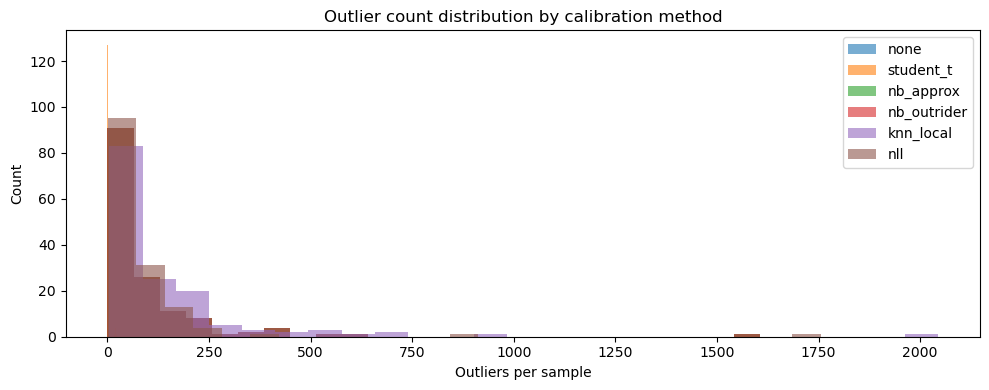

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/outliers_per_sample_by_method.png


In [62]:
import matplotlib.pyplot as plt

FIGURES.mkdir(parents=True, exist_ok=True)

if summaries:
    fig, ax = plt.subplots(figsize=(10, 4))
    for m in METHODS:
        if m in summaries and "absolute_significant_gene_count_by_alpha" in summaries[m].columns:
            s = summaries[m].sort_values("sample_id")
            ax.hist(s["absolute_significant_gene_count_by_alpha"], bins=25, alpha=0.6, label=m)
    ax.set_xlabel("Outliers per sample")
    ax.set_ylabel("Count")
    ax.set_title("Outlier count distribution by calibration method")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "outliers_per_sample_by_method.png", dpi=150)
    plt.show()
    print(f"Saved {FIGURES / 'outliers_per_sample_by_method.png'}")

### Rank vs N outliers per sample

**Methods**: For each method, sort samples by outlier count (ascending) and assign rank 1..n. Plot rank (x) vs n_outliers (y); one curve per method. Shows how methods differ in per-sample discovery rates.

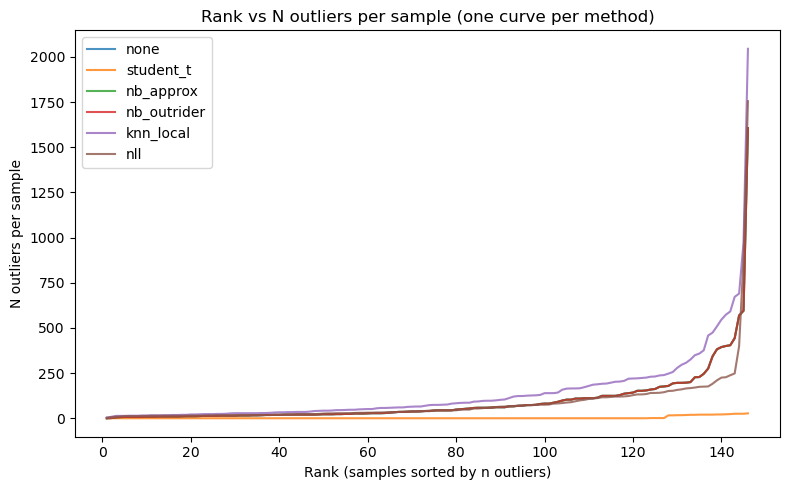

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/rank_vs_outliers_per_sample.png


In [70]:
if summaries:
    fig, ax = plt.subplots(figsize=(8, 5))
    for m in METHODS:
        if m in summaries and "absolute_significant_gene_count_by_alpha" in summaries[m].columns:
            s = summaries[m].sort_values("sample_id")
            counts = s["absolute_significant_gene_count_by_alpha"].values
            sorted_counts = np.sort(counts)
            ranks = np.arange(1, len(sorted_counts) + 1)
            ax.plot(ranks, sorted_counts, label=m, alpha=0.8)
    ax.set_xlabel("Rank (samples sorted by n outliers)")
    ax.set_ylabel("N outliers per sample")
    ax.set_title("Rank vs N outliers per sample (one curve per method)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "rank_vs_outliers_per_sample.png", dpi=150)
    plt.show()
    print(f"Saved {FIGURES / 'rank_vs_outliers_per_sample.png'}")

**Results**: Overlap table or Venn diagram; agreement across methods.

**Methods**: Fallback overlap table when matplotlib_venn not installed.

## 5b. KS statistics for calibration quality

Kolmogorov-Smirnov statistic vs Uniform(0,1) for raw p-values. Lower is better (tighter alignment with null). See paper Section 6.1.

**Results**: Overlap counts printed.

**Methods**: For samples with KNOWN_MUTATION, check if causal gene in top-K. Map symbol→Ensembl; compute recall.

In [71]:
from scipy import stats

def _get_pcol(df, method):
    """Resolve p-value column for KS vs Uniform(0,1)."""
    if method == "nb_outrider" and "nb_outrider_p_raw" in df.columns:
        return "nb_outrider_p_raw"
    if method == "nb_approx" and "nb_approx_two_sided_p_value" in df.columns:
        return "nb_approx_two_sided_p_value"
    for c in ("raw_p_value", "raw_pvalue", "p_raw"):
        if c in df.columns:
            return c
    return None

ks_results = {}
for m in METHODS:
    if m not in outliers or outliers[m] is None or len(outliers[m]) == 0:
        continue
    df = outliers[m]
    pcol = _get_pcol(df, m)
    if pcol is None:
        continue
    # Use non-outlier p-values only (null distribution) for calibration quality
    if "is_significant" in df.columns:
        df_null = df[~df["is_significant"].astype(bool)]
    else:
        df_null = df
    pvals = df_null[pcol].dropna()
    pvals = pvals[(pvals > 0) & (pvals < 1)]
    if len(pvals) < 10:
        continue
    ks_stat, _ = stats.kstest(pvals, "uniform")
    ks_results[m] = ks_stat

ks_df = pd.DataFrame({"method": list(ks_results.keys()), "KS_stat": list(ks_results.values())}).sort_values("KS_stat")
print(ks_df.to_string(index=False))

     method  KS_stat
        nll 0.014236
       none 0.015101
  nb_approx 0.015101
nb_outrider 0.015101
  knn_local 0.031661
  student_t 0.047969


**Results**: Recall at K=10, K=50 per method; validation against known mutations.

**Methods**: Plot z-score distribution (method=none): non-outlier vs outlier; z=±2 reference.

## 6. P-value distributions

**Interpretation**: Well-calibrated methods show approximately uniform histograms. NB-Outrider shows tight alignment (KS 0.027); Gaussian can show inflation at low p-values. See paper Section 6.2.1.

**Results**: Z-score histogram saved to `zscore_distribution.png`.

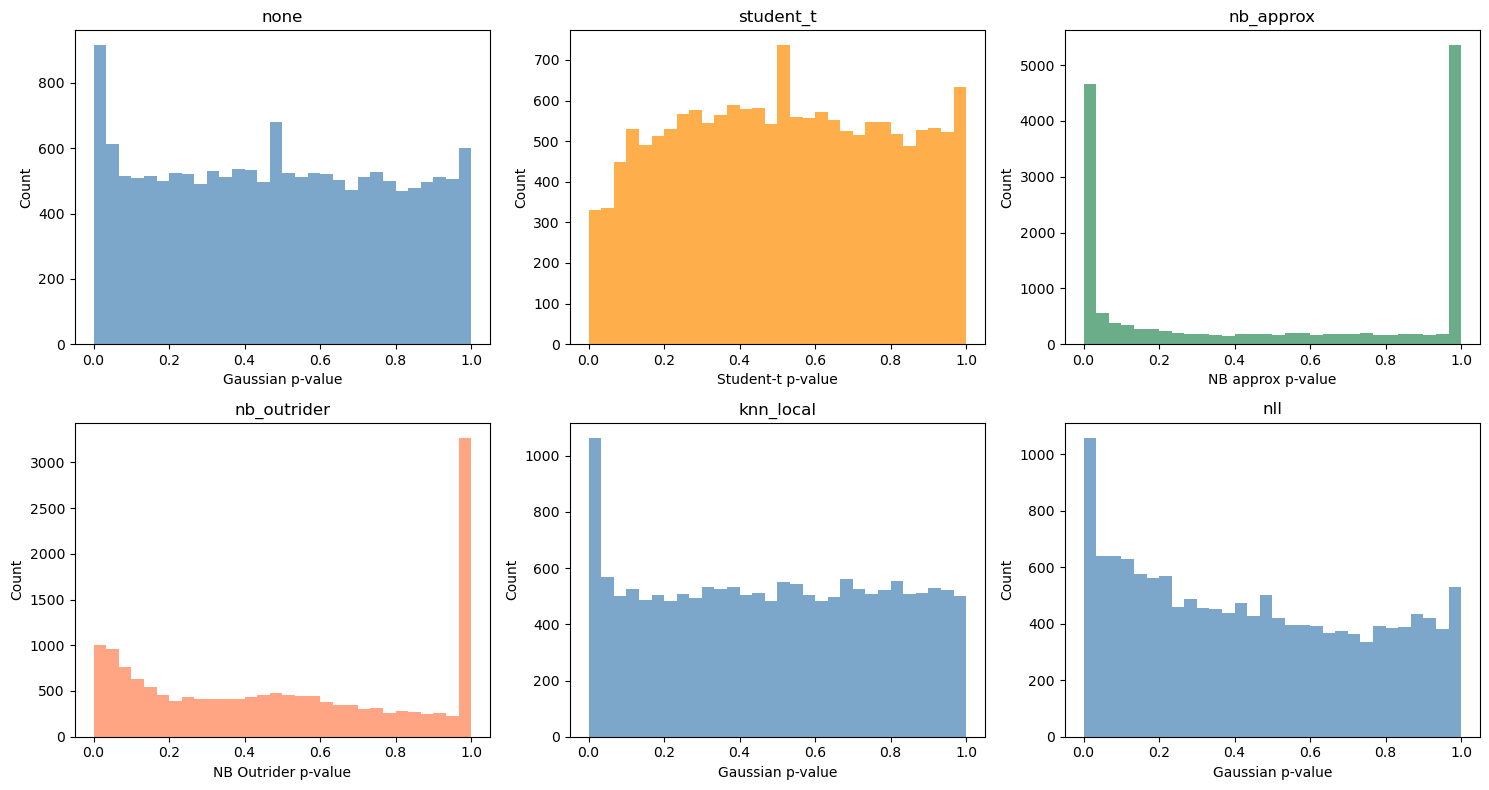

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/pvalue_distributions.png


In [72]:
import numpy as np
if ranked:
    n_methods = len([m for m in METHODS if m in ranked and ranked[m]])
    n_cols = min(3, n_methods)
    n_rows = (n_methods + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.atleast_2d(axes)
    if n_methods == 1:
        axes = axes.reshape(1, -1)
    idx = 0
    for m in METHODS:
        if m not in ranked or not ranked[m]:
            continue
        ax = axes.flat[idx]
        tbl = next(iter(ranked[m].values()))
        if m == "nb_outrider" and "nb_outrider_p_raw" in tbl.columns:
            p = tbl["nb_outrider_p_raw"].dropna()
            ax.hist(p, bins=30, alpha=0.7, color="coral")
            ax.set_xlabel("NB Outrider p-value")
        elif m == "nb_approx" and "nb_approx_two_sided_p_value" in tbl.columns:
            p = tbl["nb_approx_two_sided_p_value"].dropna()
            ax.hist(p, bins=30, alpha=0.7, color="seagreen")
            ax.set_xlabel("NB approx p-value")
        elif m == "student_t" and "raw_p_value" in tbl.columns:
            p = tbl["raw_p_value"].dropna()
            ax.hist(p, bins=30, alpha=0.7, color="darkorange")
            ax.set_xlabel("Student-t p-value")
        elif "raw_p_value" in tbl.columns:
            p = tbl["raw_p_value"].dropna()
            ax.hist(p, bins=30, alpha=0.7, color="steelblue")
            ax.set_xlabel("Gaussian p-value")
        elif "empirical_p_value" in tbl.columns:
            p = tbl["empirical_p_value"].dropna()
            ax.hist(p, bins=30, alpha=0.7, color="gray")
            ax.set_xlabel("Empirical p-value")
        else:
            continue
        ax.set_ylabel("Count")
        ax.set_title(m)
        idx += 1
    for j in range(idx, axes.size):
        axes.flat[j].set_visible(False)
    fig.tight_layout()
    fig.savefig(FIGURES / "pvalue_distributions.png", dpi=150)
    plt.show()
    print(f"Saved {FIGURES / 'pvalue_distributions.png'}")

### QQ plots and volcano plots

**QQ plots**: Theoretical quantiles of Uniform(0,1) vs empirical quantiles of p-values. Well-calibrated methods lie on the diagonal.

**Volcano plots**: X = anomaly_score, Y = -log10(p_value). Points colored by significance. One subplot per method.

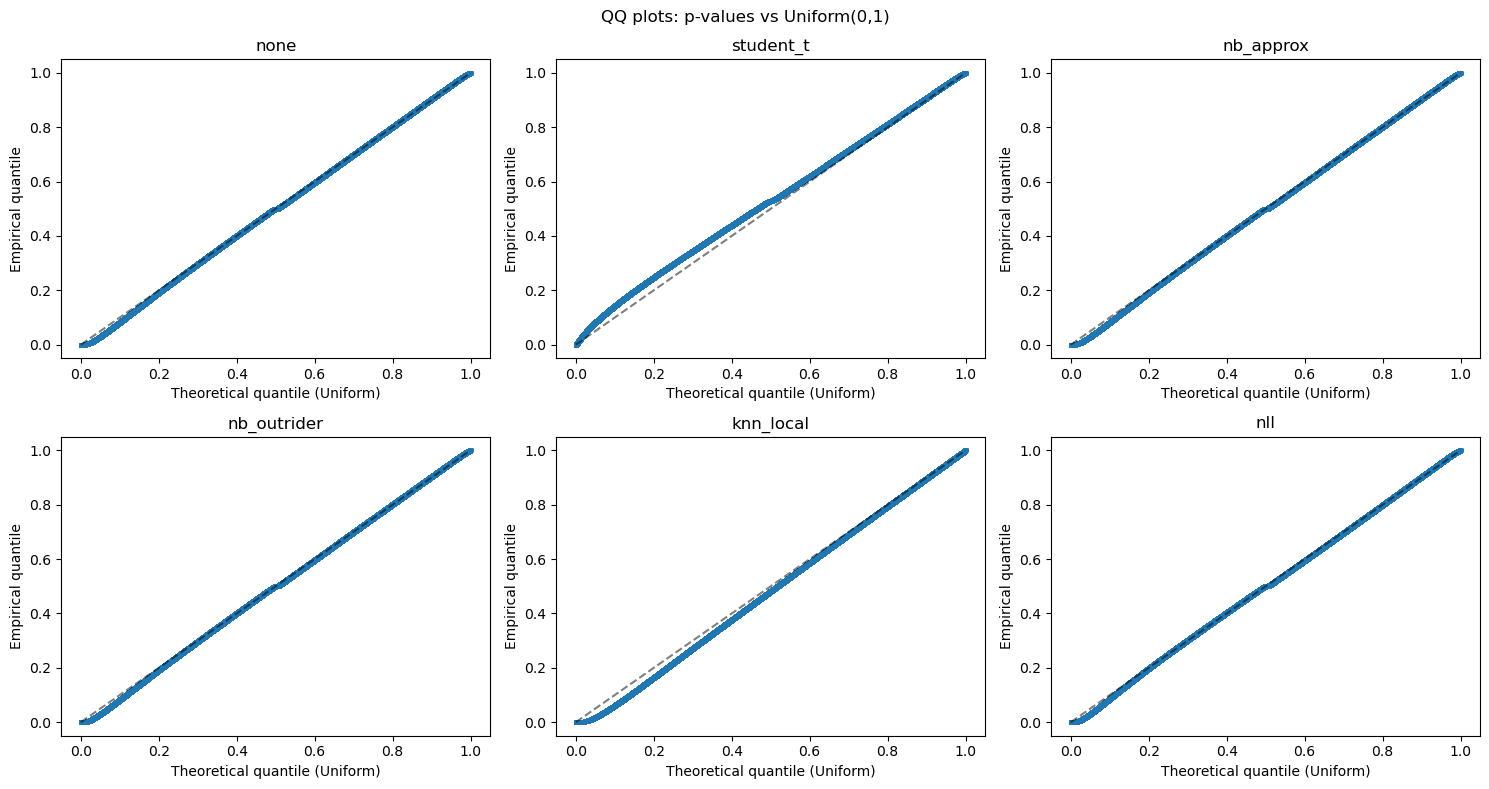

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/qq_plots.png


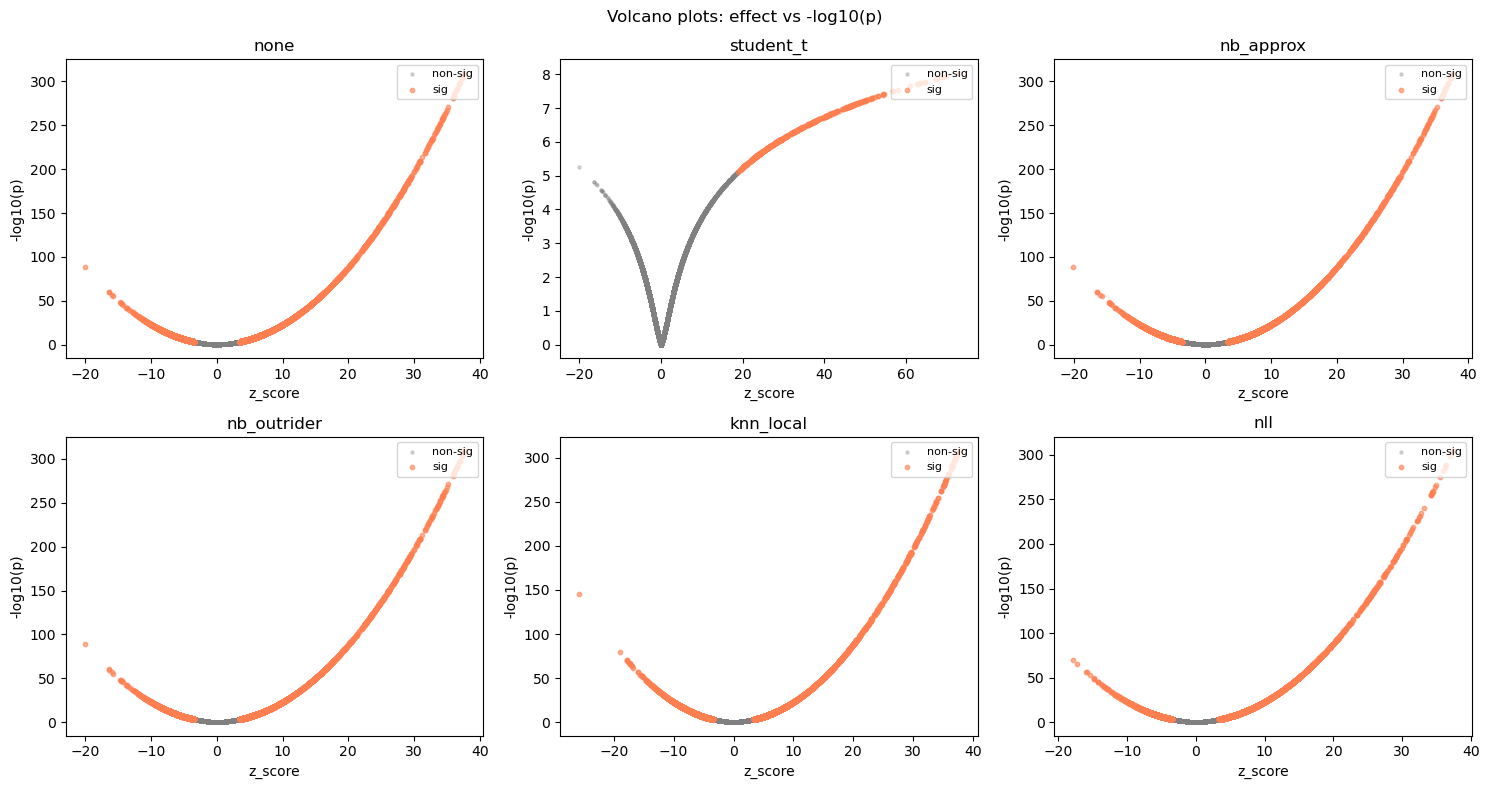

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/volcano_plots.png


In [73]:
def _get_pcol_qq(df, method):
    """Resolve p-value column for QQ/volcano."""
    if method == "nb_outrider" and "nb_outrider_p_raw" in df.columns:
        return "nb_outrider_p_raw"
    if method == "nb_approx" and "nb_approx_two_sided_p_value" in df.columns:
        return "nb_approx_two_sided_p_value"
    for c in ("raw_p_value", "raw_pvalue", "p_raw"):
        if c in df.columns:
            return c
    return None

# QQ plots
if outliers:
    methods_with_data = [m for m in METHODS if m in outliers and outliers[m] is not None and len(outliers[m]) > 0]
    n_m = len(methods_with_data)
    if n_m > 0:
        n_cols = min(3, n_m)
        n_rows = (n_m + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
        axes = np.atleast_2d(axes)
        if n_m == 1:
            axes = axes.reshape(1, -1)
        for idx, m in enumerate(methods_with_data):
            ax = axes.flat[idx]
            df = outliers[m]
            pcol = _get_pcol_qq(df, m)
            if pcol is None:
                ax.set_title(f"{m} (no p-values)")
                continue
            pvals = df[pcol].dropna()
            pvals = pvals[(pvals > 0) & (pvals < 1)].values
            if len(pvals) < 10:
                ax.set_title(f"{m} (n<10)")
                continue
            pvals = np.sort(pvals)
            n = len(pvals)
            theoretical = np.linspace(0, 1, n + 2)[1:-1]
            ax.scatter(theoretical, pvals, alpha=0.3, s=5)
            ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
            ax.set_xlabel("Theoretical quantile (Uniform)")
            ax.set_ylabel("Empirical quantile")
            ax.set_title(m)
        fig.suptitle("QQ plots: p-values vs Uniform(0,1)")
        fig.tight_layout()
        fig.savefig(FIGURES / "qq_plots.png", dpi=150)
        plt.show()
        print(f"Saved {FIGURES / 'qq_plots.png'}")

# Volcano plots
if outliers:
    if n_m > 0:
        fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
        axes2 = np.atleast_2d(axes2)
        if n_m == 1:
            axes2 = axes2.reshape(1, -1)
        for idx, m in enumerate(methods_with_data):
            ax = axes2.flat[idx]
            df = outliers[m]
            pcol = _get_pcol_qq(df, m)
            xcol = "anomaly_score" if "anomaly_score" in df.columns else "z_score"
            if pcol is None or xcol not in df.columns:
                ax.set_title(f"{m} (missing cols)")
                continue
            valid = df[pcol].notna() & (df[pcol] > 0) & (df[pcol] < 1)
            x = df.loc[valid, xcol].values
            y = -np.log10(df.loc[valid, pcol].values)
            sig = df.loc[valid, "is_significant"].astype(bool).values if "is_significant" in df.columns else np.zeros(len(x), dtype=bool)
            ax.scatter(x[~sig], y[~sig], alpha=0.3, s=5, c="grey", label="non-sig")
            if sig.any():
                ax.scatter(x[sig], y[sig], alpha=0.6, s=10, c="coral", label="sig")
            ax.set_xlabel(xcol)
            ax.set_ylabel("-log10(p)")
            ax.set_title(m)
            ax.legend(loc="upper right", fontsize=8)
        fig2.suptitle("Volcano plots: effect vs -log10(p)")
        fig2.tight_layout()
        fig2.savefig(FIGURES / "volcano_plots.png", dpi=150)
        plt.show()
        print(f"Saved {FIGURES / 'volcano_plots.png'}")

## 7. Method comparison summary table

In [74]:
rows = []
for m in METHODS:
    if m not in summaries:
        continue
    s = summaries[m]
    col = "absolute_significant_gene_count_by_alpha"
    if col in s.columns:
        rows.append({
            "method": m,
            "mean_outliers": s[col].mean(),
            "median_outliers": s[col].median(),
            "max_outliers": s[col].max(),
        })
if rows:
    df = pd.DataFrame(rows)
    display(df)

,method,mean_outliers,median_outliers,max_outliers
0,none,93.041096,40.0,1606
1,student_t,2.705479,0.0,27
2,nb_approx,93.041096,40.0,1606
3,nb_outrider,93.041096,40.0,1606
4,knn_local,141.541096,71.0,2045
5,nll,83.493151,41.0,1755


## 8. Gene overlap (significant genes across methods)

**Interpretation**: Agreement across methods suggests robust calls; disagreement may reflect different distributional assumptions or cohort structure. Venn/overlap table shows consensus vs method-specific discoveries.

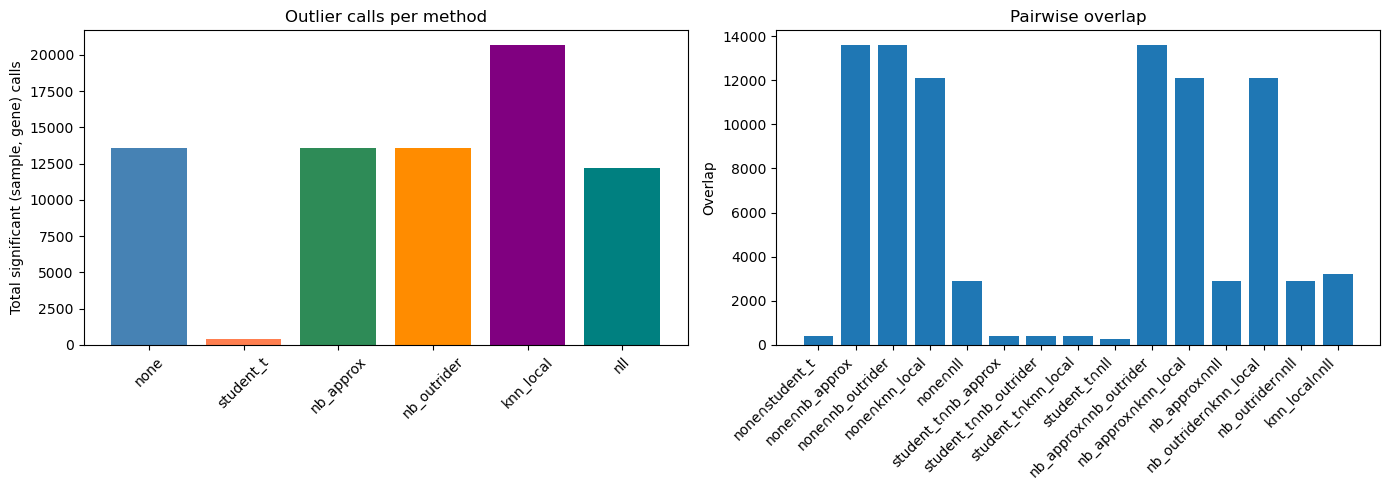

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/method_overlap.png


In [75]:
def get_sig_genes(outliers_df: pd.DataFrame) -> set[tuple[str, str]]:
    sig = outliers_df[outliers_df["is_significant"]][["sample_id", "gene"]].drop_duplicates()
    return set(zip(sig["sample_id"].astype(str), sig["gene"].astype(str)))

if outliers:
    sig_sets = {m: get_sig_genes(outliers[m]) for m in METHODS if m in outliers}
    if len(sig_sets) >= 2:
        methods = list(sig_sets.keys())
        venn_ok = False
        if len(methods) <= 3:
            try:
                from matplotlib_venn import venn2, venn3
                if len(methods) == 2:
                    fig, ax = plt.subplots(figsize=(6, 6))
                    venn2([sig_sets[methods[0]], sig_sets[methods[1]]], set_labels=methods)
                else:
                    fig, ax = plt.subplots(figsize=(8, 8))
                    venn3([sig_sets[methods[0]], sig_sets[methods[1]], sig_sets[methods[2]]], set_labels=methods)
                ax.set_title("Overlap of significant (sample, gene) calls")
                fig.savefig(FIGURES / "method_overlap_venn.png", dpi=150)
                plt.show()
                print(f"Saved {FIGURES / 'method_overlap_venn.png'}")
                venn_ok = True
            except ImportError:
                pass
        if not venn_ok or len(methods) > 3:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            colors = ["steelblue", "coral", "seagreen", "darkorange", "purple", "teal"][:len(methods)]
            axes[0].bar(methods, [len(sig_sets[m]) for m in methods], color=colors)
            axes[0].set_ylabel("Total significant (sample, gene) calls")
            axes[0].set_title("Outlier calls per method")
            axes[0].tick_params(axis="x", rotation=45)
            labels, vals = [], []
            for i, m1 in enumerate(methods):
                for m2 in methods[i+1:]:
                    labels.append(f"{m1}∩{m2}")
                    vals.append(len(sig_sets[m1] & sig_sets[m2]))
            axes[1].bar(range(len(vals)), vals)
            axes[1].set_xticks(range(len(labels)))
            axes[1].set_xticklabels(labels, rotation=45, ha="right")
            axes[1].set_ylabel("Overlap")
            axes[1].set_title("Pairwise overlap")
            fig.tight_layout()
            fig.savefig(FIGURES / "method_overlap.png", dpi=150)
            plt.show()
            print(f"Saved {FIGURES / 'method_overlap.png'}")
    else:
        print("Need at least 2 methods for overlap plot.")
else:
    print("No outlier tables loaded.")

### Overlap table (fallback)

**Methods**: Fallback when `matplotlib_venn` not installed; prints pairwise overlap counts.

In [76]:
# Fallback: overlap table if matplotlib_venn not installed
def overlap_table(sig_sets: dict[str, set]) -> pd.DataFrame:
    methods = list(sig_sets.keys())
    rows = []
    for m in methods:
        for m2 in methods:
            if m <= m2:
                inter = len(sig_sets[m] & sig_sets[m2])
                rows.append({"method_a": m, "method_b": m2, "overlap": inter})
    return pd.DataFrame(rows)

if outliers and len(outliers) >= 2:
    sig_sets = {m: get_sig_genes(outliers[m]) for m in METHODS if m in outliers}
    display(overlap_table(sig_sets))

,method_a,method_b,overlap
0,none,none,13584
1,none,student_t,395
2,student_t,student_t,395
3,nb_approx,none,13584
4,nb_approx,student_t,395
5,nb_approx,nb_approx,13584
6,nb_approx,nb_outrider,13584
7,nb_approx,nll,2903
8,nb_outrider,none,13584
9,nb_outrider,student_t,395


## 8b. Known-Mutation Gene Recall

For samples with KNOWN_MUTATION in sample_annotation, check if the causal gene appears in top-K outliers. Recall@K = fraction of such samples where the known gene is in top K. NLL is recommended for single-sample causal prioritization (paper Section 5.1 Mode A).

In [77]:
# Known-mutation gene recall: map symbol -> Ensembl, then check top-K
ann = pd.read_csv(ROOT / "data" / "clinical_rnaseq" / "sample_annotation.tsv", sep="\t")
gene_ann = pd.read_csv(ROOT / "data" / "clinical_rnaseq" / "gene_annotation_v29.tsv", sep="\t")
symbol_to_ensg = gene_ann.drop_duplicates("gene_name").set_index("gene_name")["gene_id"].astype(str).str.split(".").str[0].to_dict()

cohort_ids = pd.read_csv(SCORE_DIR / "cohort_scores.tsv", sep="\t")["sample_id"].astype(str)
known = ann[ann["KNOWN_MUTATION"].notna() & (ann["KNOWN_MUTATION"] != "NA") & (ann["KNOWN_MUTATION"] != "CONTROL")][["SAMPLE_ID", "KNOWN_MUTATION"]]
known = known[known["SAMPLE_ID"].astype(str).isin(cohort_ids.tolist())]

def recall_at_k(ranked_dict, sample_id, ensg_id, k):
    if sample_id not in ranked_dict:
        return None
    df = ranked_dict[sample_id]
    gcol = "ensg_id" if "ensg_id" in df.columns else "gene"
    df = df.sort_values("anomaly_score", ascending=False) if "anomaly_score" in df.columns else df
    genes_topk = set(df[gcol].astype(str).str.split(".").str[0].head(k))
    return (ensg_id in genes_topk) if ensg_id else None

def median_rank(ranked_dict, sample_id, ensg_id):
    if sample_id not in ranked_dict or not ensg_id:
        return None
    df = ranked_dict[sample_id]
    gcol = "ensg_id" if "ensg_id" in df.columns else "gene"
    df = df.sort_values("anomaly_score", ascending=False).reset_index(drop=True) if "anomaly_score" in df.columns else df.reset_index(drop=True)
    df["ensg_base"] = df[gcol].astype(str).str.split(".").str[0]
    match = df[df["ensg_base"] == ensg_id]
    return int(match.index[0]) + 1 if len(match) > 0 else None

K_list = [10, 50, 100]
recall_table = []
for m in METHODS:
    if m not in ranked or not ranked[m]:
        continue
    for k in K_list:
        hits = 0
        total = 0
        for _, row in known.iterrows():
            sid, sym = str(row["SAMPLE_ID"]), row["KNOWN_MUTATION"]
            ensg = symbol_to_ensg.get(sym)
            if ensg:
                ensg = ensg.split(".")[0]
            r = recall_at_k(ranked[m], sid, ensg, k)
            if r is not None:
                total += 1
                hits += int(r)
        recall_table.append({"method": m, "K": k, "recall": hits / total if total > 0 else np.nan, "n": total})

recall_df = pd.DataFrame(recall_table)
print(recall_df.pivot(index="method", columns="K", values="recall").round(3).to_string())

K            10    50     100
method                       
knn_local    0.0  0.00  0.000
nb_approx    0.0  0.00  0.000
nb_outrider  0.0  0.00  0.000
nll          0.0  0.02  0.039
none         0.0  0.00  0.000
student_t    0.0  0.00  0.000


### Causal gene swarm plots (faceted by method)

**Methods**: For each causal gene (from KNOWN_MUTATION), show metric distribution across all samples. Non-causal samples = grey, causal samples (where KNOWN_MUTATION = that gene) = red. Faceted by method: columns = methods, rows = genes. X-axis = anomaly_score.

In [ ]:
import seaborn as sns

# Build long-format data for causal gene swarm: sample_id, gene_symbol, method, metric, is_causal
causal_genes = known["KNOWN_MUTATION"].dropna().unique().tolist()
if not causal_genes:
    print("No causal genes (KNOWN_MUTATION) for swarm plots.")
else:
    rows = []
    for sym in causal_genes:
        ensg = symbol_to_ensg.get(sym)
        if ensg:
            ensg = str(ensg).split(".")[0]
        else:
            continue
        causal_samples = set(known[known["KNOWN_MUTATION"] == sym]["SAMPLE_ID"].astype(str))
        for sid in cohort_ids.astype(str):
            is_causal = sid in causal_samples
            for m in METHODS:
                if m not in ranked or not ranked[m] or sid not in ranked[m]:
                    continue
                tbl = ranked[m][sid]
                gcol = "ensg_id" if "ensg_id" in tbl.columns else "gene"
                tbl_ensg = tbl[gcol].astype(str).str.split(".").str[0]
                match = tbl[tbl_ensg == ensg]
                if len(match) == 0:
                    continue
                metric = float(match["anomaly_score"].iloc[0])
                if not np.isfinite(metric):
                    continue
                rows.append({"sample_id": sid, "gene": sym, "method": m, "metric": metric, "is_causal": is_causal})
    if rows:
        swarm_df = pd.DataFrame(rows)
        g = sns.FacetGrid(swarm_df, col="method", row="gene", sharex=True, sharey="row", height=2.5, aspect=1.2)
        g.map_dataframe(
            sns.stripplot, x="metric", y="gene", hue="is_causal", orient="h", native_scale=True,
            palette={False: "lightgrey", True: "red"}, alpha=0.8, size=4, dodge=False
        )
        g.add_legend(title="Causal")
        g.set_axis_labels("anomaly_score", "Gene")
        g.tight_layout()
        g.savefig(FIGURES / "causal_gene_swarm_by_method.png", dpi=150)
        plt.show()
        print(f"Saved {FIGURES / 'causal_gene_swarm_by_method.png'}")
    else:
        print("No metric data for causal genes.")

### AUC-ROC and AUC-PR on causal genes

**Methods**: For each calibration method, treat causal gene prioritization as binary classification: ground truth = 1 if (sample, gene) is a known causal pair, 0 otherwise. Score = anomaly_score (higher = more anomalous). Pool all (sample, gene) pairs across samples with KNOWN_MUTATION. Compute ROC curve, AUC-ROC, precision-recall curve, and AUC-PR per method.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# Build ground truth: (sample_id, ensg_id) -> is_causal
causal_pairs = set()
for _, row in known.iterrows():
    sid = str(row["SAMPLE_ID"])
    sym = row["KNOWN_MUTATION"]
    ensg = symbol_to_ensg.get(sym)
    if ensg:
        ensg = str(ensg).split(".")[0]
        causal_pairs.add((sid, ensg))

if causal_pairs and ranked:
    methods_with_ranked = [m for m in METHODS if m in ranked and ranked[m]]
    if methods_with_ranked:
        n_m = len(methods_with_ranked)
        n_cols = min(2, n_m)
        n_rows = (n_m + n_cols - 1) // n_cols

        # AUC-ROC figure
        fig_roc, axes_roc = plt.subplots(1, 1, figsize=(6, 5))
        ax_roc = axes_roc
        for m in methods_with_ranked:
            y_true, y_score = [], []
            for (sid, ensg) in causal_pairs:
                if sid not in ranked[m]:
                    continue
                tbl = ranked[m][sid]
                gcol = "ensg_id" if "ensg_id" in tbl.columns else "gene"
                tbl_ensg = tbl[gcol].astype(str).str.split(".").str[0]
                for _, r in tbl.iterrows():
                    g = str(r[gcol]).split(".")[0]
                    is_causal = (sid, g) in causal_pairs
                    sc = r.get("anomaly_score", np.nan)
                    if np.isfinite(sc):
                        y_true.append(1 if is_causal else 0)
                        y_score.append(float(sc))
            if len(y_true) < 2 or sum(y_true) == 0:
                continue
            y_true = np.array(y_true)
            y_score = np.array(y_score)
            auc = roc_auc_score(y_true, y_score)
            fpr, tpr, _ = roc_curve(y_true, y_score)
            ax_roc.plot(fpr, tpr, label=f"{m} (AUC={auc:.3f})", lw=2)
        ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
        ax_roc.set_xlabel("False positive rate")
        ax_roc.set_ylabel("True positive rate")
        ax_roc.set_title("AUC-ROC: causal gene prioritization")
        ax_roc.legend(loc="lower right", fontsize=8)
        ax_roc.set_xlim(0, 1)
        ax_roc.set_ylim(0, 1)
        fig_roc.tight_layout()
        fig_roc.savefig(FIGURES / "auc_roc_causal_genes.png", dpi=150)
        plt.show()
        print(f"Saved {FIGURES / 'auc_roc_causal_genes.png'}")

        # AUC-PR figure
        fig_pr, axes_pr = plt.subplots(1, 1, figsize=(6, 5))
        ax_pr = axes_pr
        for m in methods_with_ranked:
            y_true, y_score = [], []
            for (sid, ensg) in causal_pairs:
                if sid not in ranked[m]:
                    continue
                tbl = ranked[m][sid]
                gcol = "ensg_id" if "ensg_id" in tbl.columns else "gene"
                for _, r in tbl.iterrows():
                    g = str(r[gcol]).split(".")[0]
                    is_causal = (sid, g) in causal_pairs
                    sc = r.get("anomaly_score", np.nan)
                    if np.isfinite(sc):
                        y_true.append(1 if is_causal else 0)
                        y_score.append(float(sc))
            if len(y_true) < 2 or sum(y_true) == 0:
                continue
            y_true = np.array(y_true)
            y_score = np.array(y_score)
            auc_pr = average_precision_score(y_true, y_score)
            prec, rec, _ = precision_recall_curve(y_true, y_score)
            ax_pr.plot(rec, prec, label=f"{m} (AUC-PR={auc_pr:.3f})", lw=2)
        ax_pr.set_xlabel("Recall")
        ax_pr.set_ylabel("Precision")
        ax_pr.set_title("AUC-PR: causal gene prioritization")
        ax_pr.legend(loc="upper right", fontsize=8)
        ax_pr.set_xlim(0, 1)
        ax_pr.set_ylim(0, 1)
        fig_pr.tight_layout()
        fig_pr.savefig(FIGURES / "auc_pr_causal_genes.png", dpi=150)
        plt.show()
        print(f"Saved {FIGURES / 'auc_pr_causal_genes.png'}")
else:
    print("No causal pairs or ranked data for AUC-ROC/AUC-PR.")

### Per-sample volcano plots (samples with causal gene)

**Methods**: For each sample with KNOWN_MUTATION, one volcano plot per calibration method. X = anomaly_score, Y = -log10(p). Highlight: (1) significant hits (is_significant), (2) causal gene (KNOWN_MUTATION for that sample). Saves one figure per sample to `volcano_per_sample_{sample_id}.png`.

In [ ]:
def _get_pcol_ranked(tbl, method):
    """Resolve p-value column for ranked table."""
    if method == "nb_outrider" and "nb_outrider_p_raw" in tbl.columns:
        return "nb_outrider_p_raw"
    if method == "nb_approx" and "nb_approx_two_sided_p_value" in tbl.columns:
        return "nb_approx_two_sided_p_value"
    for c in ("raw_p_value", "raw_pvalue", "p_raw"):
        if c in tbl.columns:
            return c
    return None

samples_with_causal = known["SAMPLE_ID"].astype(str).unique().tolist()
if samples_with_causal and ranked:
    methods_with_ranked = [m for m in METHODS if m in ranked and ranked[m]]
    for sid in samples_with_causal:
        causal_sym = known[known["SAMPLE_ID"].astype(str) == sid]["KNOWN_MUTATION"].iloc[0]
        causal_ensg = symbol_to_ensg.get(causal_sym)
        if causal_ensg:
            causal_ensg = str(causal_ensg).split(".")[0]
        else:
            causal_ensg = None
        available = [(m, ranked[m][sid]) for m in methods_with_ranked if sid in ranked[m]]
        if not available:
            continue
        n_m = len(available)
        n_cols = min(3, n_m)
        n_rows = (n_m + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
        axes = np.atleast_2d(axes)
        if n_m == 1:
            axes = axes.reshape(1, -1)
        for idx, (m, tbl) in enumerate(available):
            ax = axes.flat[idx]
            pcol = _get_pcol_ranked(tbl, m)
            gcol = "ensg_id" if "ensg_id" in tbl.columns else "gene"
            xcol = "anomaly_score" if "anomaly_score" in tbl.columns else "z_score"
            if pcol is None or xcol not in tbl.columns:
                ax.set_title(f"{m} (missing cols)")
                continue
            valid = tbl[pcol].notna() & (tbl[pcol] > 0) & (tbl[pcol] < 1)
            df = tbl.loc[valid].copy()
            df["_x"] = df[xcol].values
            df["_y"] = -np.log10(df[pcol].values)
            df["_ensg"] = df[gcol].astype(str).str.split(".").str[0]
            df["_sig"] = df["is_significant"].astype(bool).values if "is_significant" in df.columns else False
            df["_causal"] = (df["_ensg"] == causal_ensg) if causal_ensg else False
            other = df[~df["_sig"] & ~df["_causal"]]
            sig_only = df[df["_sig"] & ~df["_causal"]]
            causal_only = df[df["_causal"] & ~df["_sig"]]
            both = df[df["_sig"] & df["_causal"]]
            ax.scatter(other["_x"], other["_y"], alpha=0.3, s=5, c="grey", label="other")
            if len(sig_only) > 0:
                ax.scatter(sig_only["_x"], sig_only["_y"], alpha=0.6, s=12, c="coral", label="significant")
            if len(causal_only) > 0:
                ax.scatter(causal_only["_x"], causal_only["_y"], alpha=0.9, s=80, c="red", marker="*", label="causal", zorder=5)
            if len(both) > 0:
                ax.scatter(both["_x"], both["_y"], alpha=0.9, s=80, c="darkred", marker="*", label="causal+sig", zorder=5)
            ax.set_xlabel(xcol)
            ax.set_ylabel("-log10(p)")
            ax.set_title(m)
            ax.legend(loc="upper right", fontsize=7)
        fig.suptitle(f"Sample {sid} | causal: {causal_sym}")
        fig.tight_layout()
        out = FIGURES / f"volcano_per_sample_{sid}.png"
        fig.savefig(out, dpi=150)
        plt.show()
        print(f"Saved {out}")
else:
    print("No samples with causal genes or ranked data for per-sample volcanoes.")

## 9. Z-score distribution (absolute approach)

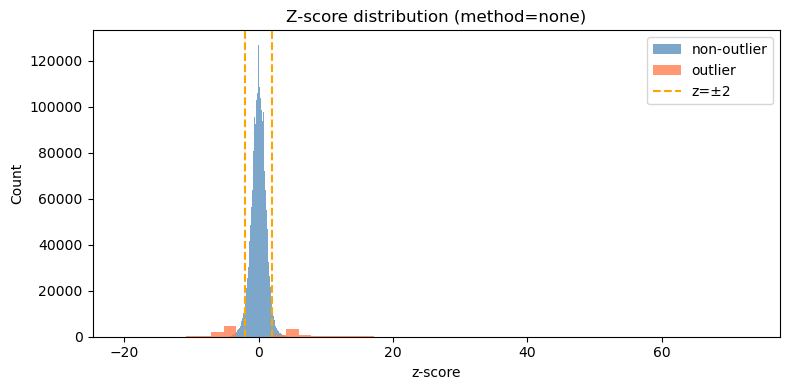

Saved /Users/Mitya/Desktop/working/BulkFormer/reports/figures/clinical_methods_comparison/zscore_distribution.png


In [69]:
if "none" in outliers:
    o = outliers["none"]
    fig, ax = plt.subplots(figsize=(8, 4))
    sig = o["is_significant"]
    ax.hist(o.loc[~sig, "z_score"], bins=80, alpha=0.7, color="steelblue", label="non-outlier")
    if sig.any():
        ax.hist(o.loc[sig, "z_score"], bins=50, alpha=0.8, color="coral", label="outlier")
    ax.axvline(-2, color="orange", linestyle="--", label="z=±2")
    ax.axvline(2, color="orange", linestyle="--")
    ax.set_xlabel("z-score")
    ax.set_ylabel("Count")
    ax.set_title("Z-score distribution (method=none)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "zscore_distribution.png", dpi=150)
    plt.show()
    print(f"Saved {FIGURES / 'zscore_distribution.png'}")